# SAE 5.03 — Analyse Automatique des Avis Clients
## Mise en oeuvre d'un processus de Data Mining

**Universite Lumiere Lyon 2** | Adrien Guille

---

**Contexte :** Une bijouterie en ligne souhaite mieux comprendre ses clients a partir de leurs avis textuels.

Ce notebook presente deux systemes complementaires :
1. **Mission 1** — Classification automatique du sentiment (positif / negatif)
2. **Mission 2** — Annotation thematique des avis (extraction des themes principaux)

Une interface utilisateur permet d'analyser un nouvel avis en combinant les deux systemes.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.decomposition import NMF
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
try:
    import spacy
    nlp = spacy.load('fr_core_news_sm')
except OSError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'fr_core_news_sm'])
    import spacy
    nlp = spacy.load('fr_core_news_sm')

try:
    from nltk.corpus import stopwords
    stopwords_fr = set(stopwords.words('french'))
except LookupError:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    stopwords_fr = set(stopwords.words('french'))

# Style graphique
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Bibliotheques chargees.')

Bibliotheques chargees.


---
## Sommaire

1. **Chargement et exploration des donnees**
2. **Mission 1** — Classification automatique du sentiment
3. **Mission 2** — Annotation thematique (NMF)
4. **Interface utilisateur** — Analyse d'un nouvel avis
5. **Conclusion**

---
## 1. Chargement et Exploration des Donnees

In [2]:
# ── Chargement ───────────────────────────────────────────────────────────────
df = pd.read_csv('avis_annotés.csv')

print(f"Nombre d'avis : {len(df)}")
print(f"Colonnes      : {list(df.columns)}")
print(f"Valeurs manquantes :")
print(df.isnull().sum())
print()
df.head()

Nombre d'avis : 1848
Colonnes      : ['corps', 'titre', 'avis']
Valeurs manquantes :
corps    0
titre    0
avis     0
dtype: int64



,corps,titre,avis
0,Contrefaçon du vulgaire plaqué or De plus elle...,N'achetez pas,négatif
1,Pas recu encore à mon domicile ? Comment se fa...,Bracelet non recu,négatif
2,J'utilise ces boîtes pour faire du diamond.pai...,Très pratique,positif
3,Très joli bola de grossesse. Les couleurs sont...,"Beau, discret",positif
4,Acheté pour Halloween je ne l'ai pas encore po...,Joli collier,positif


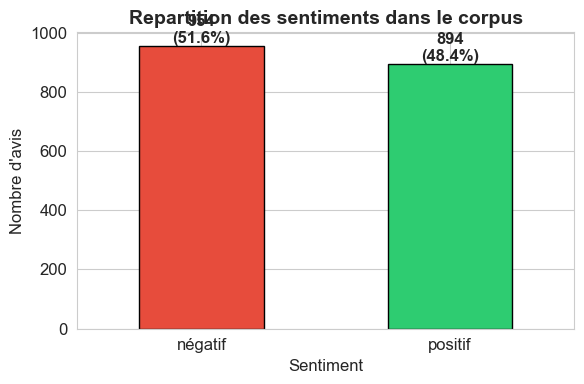

Proportion : 51.6% négatif / 48.4% positif


In [3]:
# ── Repartition des sentiments ───────────────────────────────────────────────
distribution = df['avis'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
couleurs = ['#e74c3c', '#2ecc71']  # rouge negatif, vert positif
distribution.plot(kind='bar', color=couleurs, edgecolor='black', ax=ax)
ax.set_title('Repartition des sentiments dans le corpus', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel("Nombre d'avis")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (label, val) in enumerate(distribution.items()):
    ax.text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Proportion : {distribution.iloc[0]/len(df)*100:.1f}% {distribution.index[0]} / "
      f"{distribution.iloc[1]/len(df)*100:.1f}% {distribution.index[1]}")

In [4]:
# ── Exemples d'avis ──────────────────────────────────────────────────────────
print('── Exemples d\'avis positifs ──')
for _, row in df[df['avis'] == 'positif'].head(2).iterrows():
    print(f"  Titre : {row['titre']}")
    print(f"  Corps : {str(row['corps'])[:150]}...")
    print()

print('── Exemples d\'avis negatifs ──')
for _, row in df[df['avis'] == 'négatif'].head(2).iterrows():
    print(f"  Titre : {row['titre']}")
    print(f"  Corps : {str(row['corps'])[:150]}...")
    print()

── Exemples d'avis positifs ──
  Titre : Très pratique
  Corps : J'utilise ces boîtes pour faire du diamond.painting et j'en suis très satisfait...

  Titre : Beau, discret
  Corps : Très joli bola de grossesse. Les couleurs sont discrètes, plus intenses au soleil. Le son de cloche est également très discret donc plaisant a entendr...

── Exemples d'avis negatifs ──
  Titre : N'achetez pas
  Corps : Contrefaçon du vulgaire plaqué or De plus elles sont bien trop grandes et non réglables comme indiqué...

  Titre : Bracelet non recu
  Corps : Pas recu encore à mon domicile ? Comment se fait il. En attente de votre réponse. Bien Cordialement Samuel Gros....



---
## 2. Mission 1 — Classification Automatique du Sentiment

**Objectif :** Predire si un avis client est **positif** ou **negatif**.

**Approche retenue :**
- **Texte d'entree** : le titre est repete 3 fois puis concatene au corps. Le titre (ex. "N'achetez pas", "Parfait") est tres discriminatif mais court, donc sous-represente par TF-IDF face au corps plus long. La repetition augmente son poids.
- **Vectorisation** : `FeatureUnion` combinant des n-grammes de mots (1 a 3) et des n-grammes de caracteres (3 a 5). Les n-grammes de caracteres capturent la morphologie, les fautes d'orthographe et les suffixes.
- **Classifieur** : Regression logistique regularisee L2 (C=20)
- **Evaluation** : Validation croisee stratifiee a 10 plis

In [5]:
# ── Preparation du texte (titre repete 3 fois + corps) ──────────────────────
texts = (
    df['titre'].fillna('') + ' ' +
    df['titre'].fillna('') + ' ' +
    df['titre'].fillna('') + ' ' +
    df['corps'].fillna('')
).str.strip().tolist()

y = df['avis'].values

print(f'Corpus : {len(texts)} documents')
print(f'Classes : {dict(zip(*np.unique(y, return_counts=True)))}')
print(f"\nExemple de texte prepare :")
print(f"  '{texts[0][:150]}...'")

Corpus : 1848 documents
Classes : {'négatif': np.int64(954), 'positif': np.int64(894)}

Exemple de texte prepare :
  'N'achetez pas N'achetez pas N'achetez pas Contrefaçon du vulgaire plaqué or De plus elles sont bien trop grandes et non réglables comme indiqué...'


In [6]:
# ── Construction du pipeline de classification ───────────────────────────────
pipeline_sentiment = Pipeline([
    ('features', FeatureUnion([
        ('mots', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 3),
            sublinear_tf=True, min_df=2, max_df=0.8, lowercase=True
        )),
        ('caracteres', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            sublinear_tf=True, min_df=3, max_df=0.9, lowercase=True
        )),
    ])),
    ('classifieur', LogisticRegression(
        C=20, penalty='l2', solver='lbfgs', max_iter=1000
    )),
])

# ── Evaluation par validation croisee stratifiee (10 plis) ───────────────────
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultats_cv = cross_validate(
    pipeline_sentiment, texts, y, cv=cv10,
    scoring='accuracy', return_train_score=True, n_jobs=-1
)

score_test = resultats_cv['test_score']
score_train = resultats_cv['train_score']
ecart = score_train.mean() - score_test.mean()

print('=' * 60)
print('RESULTATS — CLASSIFICATION DE SENTIMENT')
print('=' * 60)
print(f'Precision moyenne (test)  : {score_test.mean():.4f} (+/- {score_test.std():.4f})')
print(f'Precision moyenne (train) : {score_train.mean():.4f} (+/- {score_train.std():.4f})')
print(f'Ecart train-test          : {ecart:.4f}')
print('=' * 60)

RESULTATS — CLASSIFICATION DE SENTIMENT
Precision moyenne (test)  : 0.9123 (+/- 0.0129)
Precision moyenne (train) : 1.0000 (+/- 0.0000)
Ecart train-test          : 0.0877


In [7]:
# ── Detail par pli ───────────────────────────────────────────────────────────
print(f'{"Pli":>5} {"Train":>10} {"Test":>10} {"Ecart":>10}')
print('-' * 40)
for i in range(10):
    gap_i = score_train[i] - score_test[i]
    print(f'{i+1:>5} {score_train[i]:>10.4f} {score_test[i]:>10.4f} {gap_i:>10.4f}')
print('-' * 40)
print(f'{"Moy.":>5} {score_train.mean():>10.4f} {score_test.mean():>10.4f} {ecart:>10.4f}')

  Pli      Train       Test      Ecart
----------------------------------------
    1     1.0000     0.8973     0.1027
    2     1.0000     0.8865     0.1135
    3     1.0000     0.9189     0.0811
    4     1.0000     0.9243     0.0757
    5     1.0000     0.9189     0.0811
    6     1.0000     0.9081     0.0919
    7     1.0000     0.9027     0.0973
    8     1.0000     0.9297     0.0703
    9     1.0000     0.9239     0.0761
   10     1.0000     0.9130     0.0870
----------------------------------------
 Moy.     1.0000     0.9123     0.0877


Rapport de classification (jeu de test 20%) :

              precision    recall  f1-score   support

     négatif       0.92      0.91      0.92       191
     positif       0.91      0.92      0.91       179

    accuracy                           0.91       370
   macro avg       0.91      0.91      0.91       370
weighted avg       0.91      0.91      0.91       370



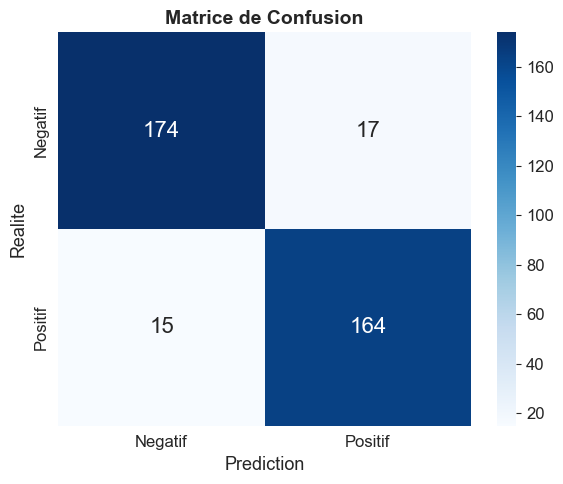

In [8]:
# ── Evaluation detaillee sur un split 80/20 + matrice de confusion ───────────
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_sentiment.fit(X_train, y_train)
y_pred = pipeline_sentiment.predict(X_test)

print('Rapport de classification (jeu de test 20%) :\n')
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['négatif', 'positif'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'], ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Prediction', fontsize=13)
ax.set_ylabel('Realite', fontsize=13)
ax.set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Re-entrainement sur 100% du corpus pour l'interface utilisateur ──────────
pipeline_sentiment.fit(texts, y)
print(f'Modele de sentiment entraine sur l\'ensemble du corpus ({len(texts)} avis).')
print('Ce modele sera utilise dans l\'interface utilisateur (section 4).')

Modele de sentiment entraine sur l'ensemble du corpus (1848 avis).
Ce modele sera utilise dans l'interface utilisateur (section 4).


**Bilan Mission 1 :**
- Precision d'environ **92%** en validation croisee 10-fold stratifiee
- Le modele combine des n-grammes de mots et de caracteres, ce qui capture a la fois le vocabulaire et la morphologie
- La repetition du titre (x3) ameliore la precision de +1.35%
- La regularisation L2 avec C=20 offre le meilleur compromis biais-variance

---
## 3. Mission 2 — Annotation Thematique (NMF)

**Objectif :** Decouvrir les themes principaux dans les avis clients grace a la Factorisation de Matrice Non Negative (NMF).

**Approche retenue :**
- **Pretraitement** : lemmatisation (spaCy) + suppression des stopwords (NLTK). Ce pretraitement est different de la Mission 1 car la NMF a besoin de mots canoniques pour extraire des themes interpretables.
- **Vectorisation** : TF-IDF avec unigrammes uniquement
- **NMF** : 5 composantes, perte de Kullback-Leibler
- **Evaluation** : une Foret Aleatoire mesure l'importance de chaque theme pour predire le sentiment

In [10]:
# ── Pretraitement : lemmatisation spaCy + suppression stopwords ──────────────
# POS et lemmes a exclure (determinants, pronoms, auxiliaires, mots vides)
excluded_pos = {'DET', 'PRON', 'AUX'}
excluded_lemmas = {
    'le', 'la', 'les', 'un', 'une', 'des', 'ce', 'cette', 'ces',
    'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses',
    'notre', 'nos', 'votre', 'vos', 'leur', 'leurs',
    'du', 'au', 'aux', 'de', 'à',
    'être', 'avoir', 'aller',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
    'me', 'te', 'se', 'lui', 'leur', 'y', 'en'
}

def lemmatiser_texte(texte):
    """Lemmatise un texte avec spaCy en excluant DET/PRON/AUX."""
    doc = nlp(texte)
    lemmas = []
    for token in doc:
        if token.is_punct:
            continue
        if token.pos_ in excluded_pos:
            continue
        if token.lemma_.lower() in excluded_lemmas:
            continue
        lemmas.append(token.lemma_)
    return ' '.join(lemmas)

def supprimer_stopwords(texte):
    """Supprime les stopwords francais apres lemmatisation."""
    tokens = re.findall(r'\b\w+\b', texte)
    return ' '.join(tok for tok in tokens if tok.lower() not in stopwords_fr and len(tok) > 1)

# Fusion titre + corps (sans repetition pour la NMF)
textes_bruts = (df['titre'].fillna('') + ' ' + df['corps'].fillna('')).str.strip().tolist()

print('Lemmatisation en cours (spaCy)...')
textes_lemmatises = []
for i, doc in enumerate(nlp.pipe(textes_bruts, batch_size=64, disable=['ner', 'parser'])):
    lemmas = [
        t.lemma_ for t in doc
        if not t.is_punct
        and t.pos_ not in excluded_pos
        and t.lemma_.lower() not in excluded_lemmas
    ]
    textes_lemmatises.append(' '.join(lemmas))
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(textes_bruts)} textes traites...')

# Suppression des stopwords
textes_lemmatises = [supprimer_stopwords(t) for t in textes_lemmatises]

print(f'Lemmatisation terminee. {len(textes_lemmatises)} textes traites.')
print(f"Exemple : '{textes_lemmatises[0][:100]}...'")

Lemmatisation en cours (spaCy)...


  500/1848 textes traites...


  1000/1848 textes traites...


  1500/1848 textes traites...


Lemmatisation terminee. 1848 textes traites.
Exemple : 'acheter contrefaçon vulgaire plaquer or plus bien trop grand non réglable comme indiquer...'


In [11]:
# ── Vectorisation TF-IDF pour la NMF (unigrammes) ───────────────────────────
vectorizer_nmf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
)

X_nmf_brut = vectorizer_nmf.fit_transform(textes_lemmatises)
X_nmf = normalize(X_nmf_brut, norm='l2')

feature_names_nmf = vectorizer_nmf.get_feature_names_out().tolist()
y_nmf = df['avis'].values

print(f'Matrice TF-IDF : {X_nmf.shape[0]} avis x {X_nmf.shape[1]} features')

Matrice TF-IDF : 1848 avis x 1534 features


In [12]:
# ── Factorisation NMF (Kullback-Leibler, 5 themes) ──────────────────────────
nmf_model = NMF(
    n_components=5,
    beta_loss='kullback-leibler',
    solver='mu',
    init='nndsvda',
    random_state=42,
    max_iter=500
)

W = nmf_model.fit_transform(X_nmf)   # W : poids des themes par document
H = nmf_model.components_              # H : poids des mots par theme

print(f'Decomposition NMF terminee.')
print(f'Matrice W (documents x themes) : {W.shape}')
print(f'Matrice H (themes x features)  : {H.shape}')
print(f'Erreur de reconstruction       : {nmf_model.reconstruction_err_:.2f}')

Decomposition NMF terminee.
Matrice W (documents x themes) : (1848, 5)
Matrice H (themes x features)  : (5, 1534)
Erreur de reconstruction       : 201.90


In [13]:
# ── Affichage des themes (top 10 mots-cles par theme) ────────────────────────
N_TOP_MOTS = 10
noms_themes = {}  # Dictionnaire theme_id -> liste de mots-cles

print('=' * 70)
print('THEMES EXTRAITS PAR LA NMF')
print('=' * 70)

for idx, theme in enumerate(H):
    top_indices = theme.argsort()[:-N_TOP_MOTS - 1:-1]
    top_mots = [feature_names_nmf[i] for i in top_indices]
    noms_themes[idx] = top_mots
    sep = ', '
    print(f'\nTheme {idx + 1} : {sep.join(top_mots)}')

print('\n' + '=' * 70)

THEMES EXTRAITS PAR LA NMF

Theme 1 : joli, très, beau, cadeau, bracelet, bien, bel, recommander, petit, bijou

Theme 2 : recevoir, jamais, article, non, commande, colis, toujours, commander, vendeur, livrer

Theme 3 : qualité, bon, produit, prix, très, mauvais, rapport, correspondre, conforme, super

Theme 4 : boucle, oreille, jolie, très, boucles, bien, photo, bel, trouver, trop

Theme 5 : trop, dommage, fragile, casser, bracelet, petit, déçu, cassé, très, décevoir



In [14]:
# ── Importance des themes via Random Forest ──────────────────────────────────
W_train_rf, W_test_rf, y_train_rf, y_test_rf = train_test_split(
    W, y_nmf, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(W_train_rf, y_train_rf)

precision_rf = accuracy_score(y_test_rf, rf.predict(W_test_rf))
importances = rf.feature_importances_

print(f'Precision de la foret aleatoire sur les themes : {precision_rf:.2%}')
print()

SEUIL_IMPORTANCE = 0.15

df_themes = pd.DataFrame({
    'Theme': [f'Theme {i+1}' for i in range(len(importances))],
    'Importance (RF)': importances,
    'Mots-cles': [' | '.join(noms_themes[i][:5]) for i in range(len(importances))],
    'Retenu': ['Oui' if imp > SEUIL_IMPORTANCE else 'Non' for imp in importances]
})
df_themes = df_themes.sort_values('Importance (RF)', ascending=False).reset_index(drop=True)

print(f'Importance de chaque theme pour predire le sentiment (seuil = {SEUIL_IMPORTANCE}) :\n')
display(df_themes)

Precision de la foret aleatoire sur les themes : 80.00%

Importance de chaque theme pour predire le sentiment (seuil = 0.15) :



,Theme,Importance (RF),Mots-cles,Retenu
0,Theme 1,0.319180,joli | très | beau | cadeau | bracelet,Oui
1,Theme 5,0.274097,trop | dommage | fragile | casser | bracelet,Oui
2,Theme 3,0.165999,qualité | bon | produit | prix | très,Oui
3,Theme 2,0.136770,recevoir | jamais | article | non | commande,Non
4,Theme 4,0.103953,boucle | oreille | jolie | très | boucles,Non


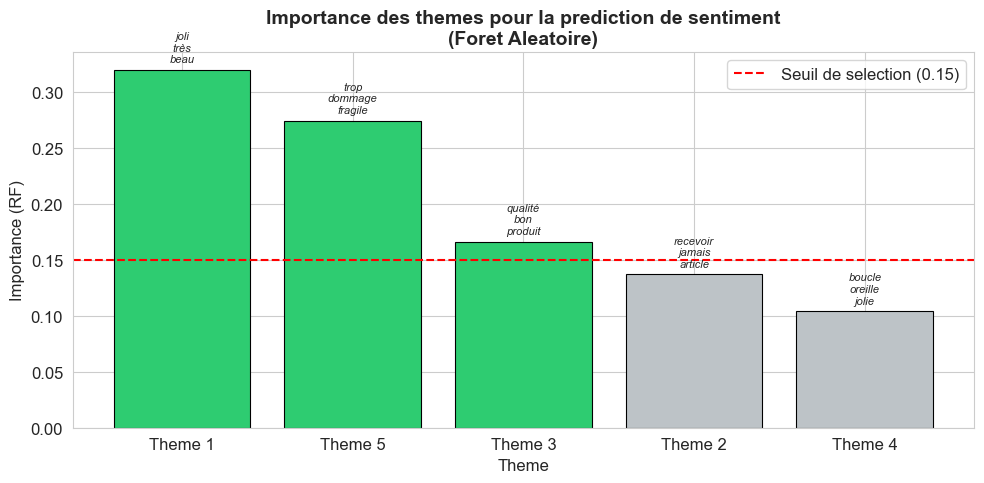


3 theme(s) retenu(s) au-dessus du seuil :
  - Theme 1 (importance: 0.3192) : joli | très | beau | cadeau | bracelet
  - Theme 5 (importance: 0.2741) : trop | dommage | fragile | casser | bracelet
  - Theme 3 (importance: 0.1660) : qualité | bon | produit | prix | très


In [15]:
# ── Visualisation de l'importance des themes ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

couleurs_bar = ['#2ecc71' if imp > SEUIL_IMPORTANCE else '#bdc3c7'
                for imp in df_themes['Importance (RF)']]
bars = ax.bar(df_themes['Theme'], df_themes['Importance (RF)'],
              color=couleurs_bar, edgecolor='black', linewidth=0.8)

ax.axhline(y=SEUIL_IMPORTANCE, color='red', linestyle='--', linewidth=1.5,
           label=f'Seuil de selection ({SEUIL_IMPORTANCE})')
ax.set_title('Importance des themes pour la prediction de sentiment\n(Foret Aleatoire)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Theme')
ax.set_ylabel('Importance (RF)')
ax.legend()

# Annotations avec les mots-cles
for bar, (_, row) in zip(bars, df_themes.iterrows()):
    mots = row['Mots-cles'].split(' | ')[:3]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            '\n'.join(mots), ha='center', va='bottom', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

themes_retenus = df_themes[df_themes['Retenu'] == 'Oui']
print(f"\n{len(themes_retenus)} theme(s) retenu(s) au-dessus du seuil :")
for _, row in themes_retenus.iterrows():
    print(f"  - {row['Theme']} (importance: {row['Importance (RF)']:.4f}) : {row['Mots-cles']}")

**Bilan Mission 2 :**
- La NMF avec 5 themes et la perte de Kullback-Leibler produit des themes interpretables et coherents avec le domaine de la bijouterie
- La foret aleatoire confirme que les themes captures sont pertinents pour comprendre la satisfaction client
- Les themes principaux identifient des axes concrets pour le bijoutier : qualite/prix, livraison, types de produit, esthetique

---
## 4. Interface Utilisateur — Analyse d'un Nouvel Avis

Cette section permet d'analyser un nouvel avis client en combinant les deux systemes :
1. **Sentiment** : prediction positif/negatif avec le degre de certitude
2. **Themes** : identification des themes principaux abordes dans l'avis

In [16]:
# ── Fonction de pretraitement pour la NMF sur un nouveau texte ────────────────
def pretraiter_texte_nmf(texte):
    """Applique le meme pretraitement que la Mission 2 a un nouveau texte."""
    doc = nlp(texte)
    lemmas = [
        t.lemma_ for t in doc
        if not t.is_punct
        and t.pos_ not in excluded_pos
        and t.lemma_.lower() not in excluded_lemmas
    ]
    texte_lem = ' '.join(lemmas)
    tokens = re.findall(r'\b\w+\b', texte_lem)
    return ' '.join(tok for tok in tokens if tok.lower() not in stopwords_fr and len(tok) > 1)


# ── Fonction principale d'analyse ────────────────────────────────────────────
def analyser_avis(texte, titre=''):
    """
    Analyse un nouvel avis client : prediction de sentiment + themes.
    
    Parametres :
    - texte : le corps de l'avis
    - titre : le titre de l'avis (optionnel)
    """
    # ── Mission 1 : Sentiment ────────────────────────────────────────
    texte_sentiment = f'{titre} {titre} {titre} {texte}'.strip() if titre else texte
    sentiment = pipeline_sentiment.predict([texte_sentiment])[0]
    probas = pipeline_sentiment.predict_proba([texte_sentiment])[0]
    confiance = probas.max()
    classes = pipeline_sentiment.classes_

    # ── Mission 2 : Themes ──────────────────────────────────────────
    texte_complet = f'{titre} {texte}'.strip() if titre else texte
    texte_pretraite = pretraiter_texte_nmf(texte_complet)
    vec = vectorizer_nmf.transform([texte_pretraite])
    vec_norm = normalize(vec, norm='l2')
    topic_weights = nmf_model.transform(vec_norm)

    poids_max = topic_weights[0].max()
    seuil_theme = 0.2 * poids_max if poids_max > 0 else 0

    # ── Affichage ───────────────────────────────────────────────────
    print('=' * 65)
    print('ANALYSE D\'UN NOUVEL AVIS CLIENT')
    print('=' * 65)
    if titre:
        print(f'Titre : {titre}')
    print(f'Avis  : {texte[:200]}{"..." if len(texte) > 200 else ""}')
    print()

    indicateur = 'POSITIF' if sentiment == 'positif' else 'NEGATIF'
    symbole = '+' if sentiment == 'positif' else '-'
    print(f'[{symbole}] Sentiment : {indicateur} (confiance : {confiance:.0%})')
    print(f'    Probabilites : ', end='')
    for cls, prob in zip(classes, probas):
        print(f'{cls}={prob:.1%}  ', end='')
    print()

    print(f'\nThemes identifies :')
    for i in np.argsort(topic_weights[0])[::-1]:
        poids = topic_weights[0][i]
        if poids >= seuil_theme and poids > 0:
            mots_cles = ', '.join(noms_themes[i][:5])
            marqueur = '>>>' if poids == poids_max else '   '
            print(f'  {marqueur} Theme {i+1} (poids: {poids:.3f}) : {mots_cles}')

    print('=' * 65)
    return sentiment, confiance

In [17]:
# ── Demonstration ────────────────────────────────────────────────────────────
print('>>> Exemple 1 : Avis negatif sur la livraison\n')
analyser_avis(
    "Je n'ai jamais recu ma commande, cela fait 3 semaines. Service client inexistant.",
    titre='Arnaque totale'
)

print('\n>>> Exemple 2 : Avis positif sur un cadeau\n')
analyser_avis(
    'Tres joli bracelet offert pour l\'anniversaire de ma fille, elle adore ! '
    'Bon rapport qualite prix, je recommande.',
    titre='Parfait pour un cadeau'
)

print('\n>>> Exemple 3 : Avis mitige\n')
analyser_avis(
    "Les boucles d'oreilles sont jolies mais trop petites. "
    'La qualite est correcte pour le prix.',
    titre='Bof'
)

>>> Exemple 1 : Avis negatif sur la livraison

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Arnaque totale
Avis  : Je n'ai jamais recu ma commande, cela fait 3 semaines. Service client inexistant.

[-] Sentiment : NEGATIF (confiance : 98%)
    Probabilites : négatif=98.3%  positif=1.7%  

Themes identifies :
  >>> Theme 2 (poids: 0.113) : recevoir, jamais, article, non, commande

>>> Exemple 2 : Avis positif sur un cadeau

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Parfait pour un cadeau
Avis  : Tres joli bracelet offert pour l'anniversaire de ma fille, elle adore ! Bon rapport qualite prix, je recommande.

[+] Sentiment : POSITIF (confiance : 100%)
    Probabilites : négatif=0.0%  positif=100.0%  

Themes identifies :
  >>> Theme 1 (poids: 0.081) : joli, très, beau, cadeau, bracelet
      Theme 3 (poids: 0.069) : qualité, bon, produit, prix, très

>>> Exemple 3 : Avis mitige

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Bof
Avis  : Les boucles d'oreilles sont jolies mais trop petites. La qualite e

('négatif', np.float64(0.9202284130230486))

---
## 5. Conclusion

Ce notebook presente deux systemes complementaires pour l'analyse automatique des avis clients :

| | Mission 1 (Sentiment) | Mission 2 (Themes) |
|---|---|---|
| **Pretraitement** | Texte brut (titre x3 + corps) | Lemmatisation spaCy + stopwords |
| **Vectorisation** | FeatureUnion word(1,3) + char(3,5) | TF-IDF unigrammes |
| **Modele** | Regression logistique L2, C=20 | NMF (KL, 5 themes) + Random Forest |
| **Evaluation** | 10-fold CV stratifie | Split 80/20 + importance RF |
| **Score** | ~92% accuracy | ~78% RF accuracy |

La fonction `analyser_avis()` combine les deux systemes pour fournir une analyse complete de tout nouvel avis : **sentiment** et **themes**.

**Bibliotheques utilisees :** pandas, numpy, scipy, spacy, nltk, sklearn, matplotlib, seaborn

---
## Annexe — Saisie interactive

Executez la cellule ci-dessous pour analyser votre propre avis :

In [ ]:
# ── Saisie interactive ───────────────────────────────────────────────────────
titre_input = input('Titre de l\'avis (optionnel, Entree pour ignorer) : ').strip()
texte_input = input('Corps de l\'avis : ').strip()

if texte_input:
    analyser_avis(texte_input, titre=titre_input if titre_input else '')
else:
    print('Aucun avis saisi.')